# Notebook 3 - Week 7 Model Comparison

**Project:** Speech Emotion Recognition on RAVDESS audio-only features.

This is the Week 7 checkpoint notebook. The point is not to crown a final model yet. The point is to make MiniLearn less tiny and then compare it against sklearn models that should behave similarly.

What this notebook tracks:

1. Load the saved feature table from Notebook 2.
2. Do one stratified train/test split and keep it fixed.
3. Fit `StandardScaler` on the training split only. No test leakage.
4. Compare MiniLearn and sklearn for logistic regression, Gaussian Naive Bayes, and KNN.
5. Track accuracy, macro-F1, weighted-F1, per-class F1, confusion matrices, and a tiny KNN tune pass.

The code is intentionally kind of direct and notebook-ish. The writeup is more detailed because the comparison decisions matter more than making the code look fancy.

## 1. Imports and Paths

The notebook should work from either the project root or from inside `notebooks/`. I am adding the project root to `sys.path` so the local `minilearn` package imports without needing an editable install.

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.naive_bayes import GaussianNB as SkGaussianNB
from sklearn.neighbors import KNeighborsClassifier

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from minilearn.classifiers import GaussianNaiveBayes, KNN, LogisticRegression
from minilearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, k_fold_cross_validate
from minilearn.preprocessing import PCA, StandardScaler, train_test_split

FEATURE_PATH = ROOT / "features" / "features.csv"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
np.set_printoptions(linewidth=120)
print(ROOT)

/home/deanomeano/coursework/cse432/projects432/serProject


## 2. Load the Feature Table

This table already has one row per audio file and all of the summary audio features from Notebook 2. The target is `emotion_id`, which maps to the eight RAVDESS emotion classes.

Important: the metadata columns stay out of `X`. If I accidentally leave `emotion`, `actor`, or `filename` in the feature matrix, the comparison becomes fake because the model would be learning labels or identifiers instead of audio features.

In [2]:
df = pd.read_csv(FEATURE_PATH)

metaCols = {
    "filename", "emotion", "emotion_id", "actor", "gender", "vocalchannel",
    "intensity", "statement", "repetition", "duration",
}
featureCols = [c for c in df.columns if c not in metaCols]

X = df[featureCols].to_numpy(dtype=float)
y = df["emotion_id"].to_numpy()
labels = sorted(df["emotion_id"].unique())
emotionNames = (
    df[["emotion_id", "emotion"]]
    .drop_duplicates()
    .sort_values("emotion_id")
    .set_index("emotion_id")["emotion"]
    .to_dict()
)

print("rows, cols:", df.shape)
print("feature count:", len(featureCols))
print(emotionNames)
df[["emotion_id", "emotion"]].value_counts().sort_index()

rows, cols: (2452, 417)
feature count: 407
{1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'}


emotion_id  emotion  
1           neutral      188
2           calm         376
3           happy        376
4           sad          376
5           angry        376
6           fearful      376
7           disgust      192
8           surprised    192
Name: count, dtype: int64

## 3. Split and Scale

I am using the same split as the Week 6 run: 80/20, stratified, `random_state=432`.

The scaler step is the main thing I do not want to mess up. It is fit on `X_train` only, then reused for `X_test`. That matters especially for KNN because distance-based models are very sensitive to feature scale. It also matters for logistic regression because gradient descent behaves better when the columns are comparable.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=432, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

splitCheck = pd.DataFrame({"split": ["train", "test"], "n": [len(y_train), len(y_test)]})
print(splitCheck)
print("train scaled mean-ish:", np.abs(X_train_s.mean(axis=0)).mean())
print("test is transformed, not fit:", np.abs(X_test_s.mean(axis=0)).mean())

   split     n
0  train  1963
1   test   489
train scaled mean-ish: 5.08351375762295e-15
test is transformed, not fit: 0.03274603711766891


## 4. Tiny KNN Tuning Pass

KNN needs a value of `k`. I am not doing a giant grid search here because this is still the Week 7 baseline notebook, but I do want something better than just picking 5 because it sounds normal.

This CV happens only on the training split. The held-out test rows are still untouched until the final model comparison below.

In [4]:
knnRows = []
for k in [3, 5, 7, 9, 11]:
    folds = k_fold_cross_validate(
        lambda k=k: KNN(k=k, weights="distance"),
        X_train,
        y_train,
        n_splits=3,
        random_state=432,
        scale=True,
    )
    knnRows.append({
        "k": k,
        "cv_accuracy": np.mean([r["accuracy"] for r in folds]),
        "cv_macro_f1": np.mean([r["macro_f1"] for r in folds]),
    })

knnTune = pd.DataFrame(knnRows).sort_values("cv_macro_f1", ascending=False)
bestK = int(knnTune.iloc[0]["k"])
knnTune

,k,cv_accuracy,cv_macro_f1
0,3,0.635218,0.626686
1,5,0.595541,0.585021
2,7,0.582249,0.563998
3,9,0.559868,0.542258
4,11,0.550687,0.533558


## 5. Fit the Comparison Models

The comparison is paired on purpose:

- MiniLearn logistic regression vs sklearn logistic regression
- MiniLearn Gaussian NB vs sklearn Gaussian NB
- MiniLearn KNN vs sklearn KNN

For NB and KNN, I expect the scores to match sklearn very closely because the algorithms are simple and the same preprocessing is used. Logistic regression is allowed to differ a little because MiniLearn uses basic gradient descent while sklearn uses a much more mature optimizer.

In [5]:
models = [
    ("MiniLearn LogisticRegression", LogisticRegression(learning_rate=0.08, max_iter=1200, reg_strength=0.001, tol=1e-7), "softmax GD, week 6 params"),
    ("sklearn LogisticRegression", SkLogisticRegression(max_iter=2000, C=1.0, solver="lbfgs"), "sklearn optimizer sanity check"),
    ("MiniLearn GaussianNB", GaussianNaiveBayes(), "fast baseline, rough independence assumption"),
    ("sklearn GaussianNB", SkGaussianNB(), "same Gaussian NB idea"),
    (f"MiniLearn KNN k={bestK}", KNN(k=bestK, weights="distance"), "distance-weighted brute force KNN"),
    (f"sklearn KNN k={bestK}", KNeighborsClassifier(n_neighbors=bestK, weights="distance"), "same k and weights"),
]

rows = []
reports = {}
matrices = {}
preds = {}

for name, model, note in models:
    t0 = time.perf_counter()
    model.fit(X_train_s, y_train)
    fitSeconds = time.perf_counter() - t0

    t0 = time.perf_counter()
    pred = model.predict(X_test_s)
    predSeconds = time.perf_counter() - t0

    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "weighted_f1": f1_score(y_test, pred, average="weighted"),
        "fit_seconds": fitSeconds,
        "predict_seconds": predSeconds,
        "notes": note,
    })
    reports[name] = classification_report(y_test, pred, labels=labels)
    matrices[name] = confusion_matrix(y_test, pred, labels=labels)
    preds[name] = pred

results = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
results

,model,accuracy,macro_f1,weighted_f1,fit_seconds,predict_seconds,notes
1,sklearn LogisticRegression,0.695297,0.681215,0.695087,50.658880,0.015300,sklearn optimizer sanity check
0,MiniLearn LogisticRegression,0.689162,0.680538,0.688100,91.269395,0.015298,"softmax GD, week 6 params"
5,sklearn KNN k=3,0.685072,0.663027,0.682568,0.006286,0.520451,same k and weights
4,MiniLearn KNN k=3,0.685072,0.663027,0.682568,0.000061,12.752223,distance-weighted brute force KNN
3,sklearn GaussianNB,0.433538,0.414877,0.424842,0.027176,0.025997,same Gaussian NB idea
2,MiniLearn GaussianNB,0.433538,0.414877,0.424842,0.058505,0.032513,"fast baseline, rough independence assumption"


## 6. Quick Agreement Checks

This is a low-drama way to check whether my from-scratch versions are doing the same basic thing as sklearn.

I expect exact agreement for Gaussian NB and KNN on this run. If those differ, it probably means I mishandled variance smoothing, distance weighting, label ordering, or tie breaking. Logistic regression only needs to be close because the optimizer is different.

In [6]:
pairs = [
    ("MiniLearn LogisticRegression", "sklearn LogisticRegression"),
    ("MiniLearn GaussianNB", "sklearn GaussianNB"),
    (f"MiniLearn KNN k={bestK}", f"sklearn KNN k={bestK}"),
]

agreementRows = []
for a, b in pairs:
    agreementRows.append({
        "pair": f"{a} vs {b}",
        "same_predictions": float(np.mean(preds[a] == preds[b])),
        "macro_f1_delta": abs(reports[a]["macro avg"]["f1"] - reports[b]["macro avg"]["f1"]),
    })

pd.DataFrame(agreementRows)

,pair,same_predictions,macro_f1_delta
0,MiniLearn LogisticRegression vs sklearn Logist...,0.877301,0.000677
1,MiniLearn GaussianNB vs sklearn GaussianNB,1.000000,0.000000
2,MiniLearn KNN k=3 vs sklearn KNN k=3,1.000000,0.000000


## 7. Per-Class F1

Overall accuracy is useful, but it hides which emotions are being handled badly. This table is the one I would use in the final report notes because it shows the pattern directly.

A few things I am watching for:

- `calm` and `angry` usually do better because they have clearer acoustic patterns in this feature set.
- `sad`, `disgust`, and `surprised` are shakier because they overlap with nearby emotional tone or have fewer examples in the song side.
- NB struggles because it treats these summary features as independent, which is basically not true for MFCCs/mel features.

In [7]:
perClassRows = []
for modelName, rep in reports.items():
    row = {"model": modelName}
    for label, emotion in emotionNames.items():
        row[emotion] = rep[label]["f1"]
    row["macro_avg"] = rep["macro avg"]["f1"]
    perClassRows.append(row)

perClassF1 = pd.DataFrame(perClassRows).sort_values("macro_avg", ascending=False)
perClassF1

,model,neutral,calm,happy,sad,angry,fearful,disgust,surprised,macro_avg
1,sklearn LogisticRegression,0.613333,0.812903,0.745098,0.584416,0.794521,0.652482,0.615385,0.631579,0.681215
0,MiniLearn LogisticRegression,0.666667,0.805031,0.729730,0.556291,0.797297,0.614286,0.650000,0.625000,0.680538
5,sklearn KNN k=3,0.613333,0.800000,0.729927,0.624113,0.735484,0.683871,0.535211,0.582278,0.663027
4,MiniLearn KNN k=3,0.613333,0.800000,0.729927,0.624113,0.735484,0.683871,0.535211,0.582278,0.663027
3,sklearn GaussianNB,0.382979,0.589041,0.437956,0.283186,0.582857,0.313043,0.342857,0.387097,0.414877
2,MiniLearn GaussianNB,0.382979,0.589041,0.437956,0.283186,0.582857,0.313043,0.342857,0.387097,0.414877


## 8. Confusion Matrices

Rows are the true emotions and columns are predicted emotions. I am plotting normalized matrices because the count matrix is useful for exact totals but harder to scan.

The main comparison here is not only which model wins. I also want to see whether the sklearn and MiniLearn versions fail in the same places. If they do, then the remaining problem is probably the data/features/model family, not a bug in MiniLearn.

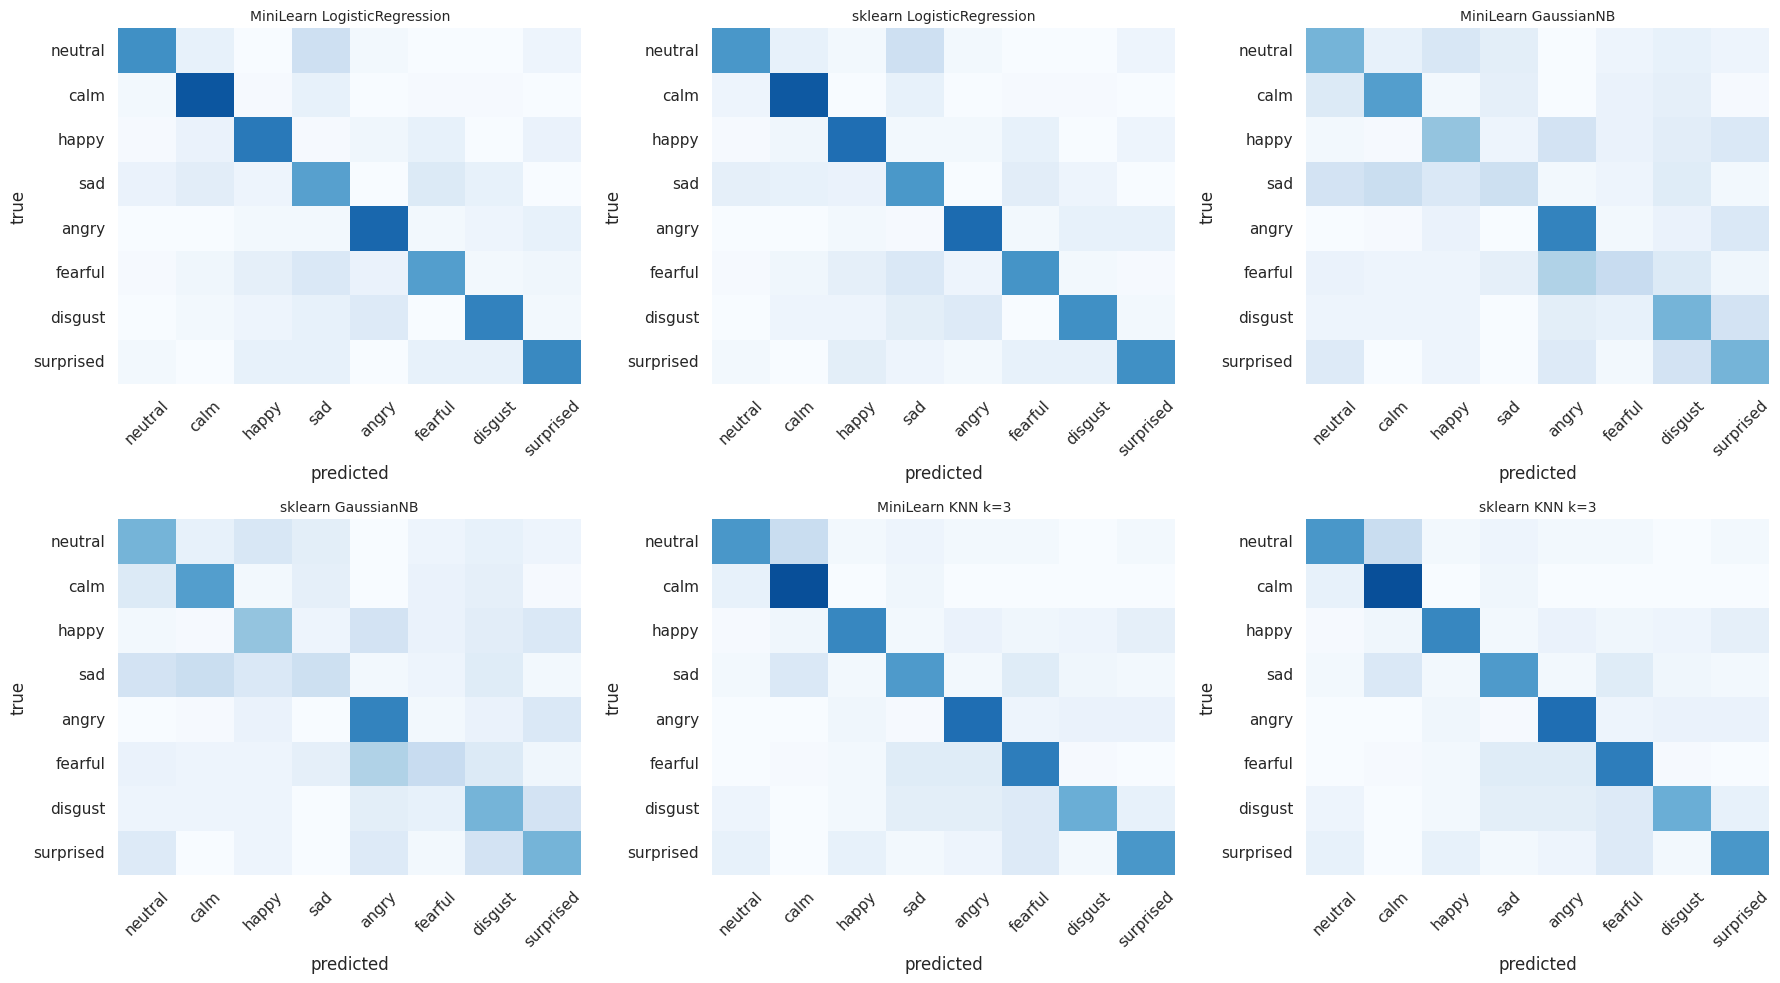

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
labelNames = [emotionNames[i] for i in labels]

for ax, (name, cm) in zip(axes, matrices.items()):
    cm = cm.astype(float)
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    sns.heatmap(
        cm_norm,
        ax=ax,
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=labelNames,
        yticklabels=labelNames,
        cbar=False,
    )
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 9. PCA View of the Test Split

This is not a classifier by itself. It is just a 2D projection of the scaled test features so I can sanity-check whether the feature table has any visible emotion structure.

If the classes are not cleanly separated in 2D, that does not mean classification is impossible. It just means the problem is not going to be solved by one super obvious visual boundary. That matches the scores: decent, but not magic.

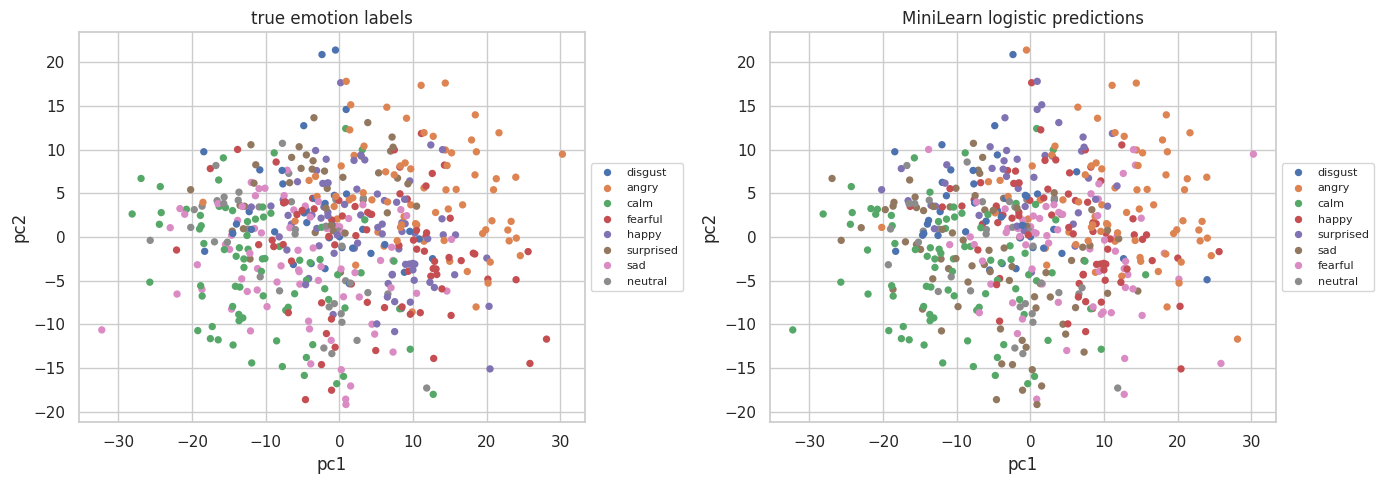

variance explained by first 2 PCs: 0.4577623421988424


In [9]:
pca = PCA(n_components=2)
Z_train = pca.fit_transform(X_train_s)
Z_test = pca.transform(X_test_s)

plotDf = pd.DataFrame({
    "pc1": Z_test[:, 0],
    "pc2": Z_test[:, 1],
    "emotion": [emotionNames[i] for i in y_test],
    "mini_lr_pred": [emotionNames[i] for i in preds["MiniLearn LogisticRegression"]],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=plotDf, x="pc1", y="pc2", hue="emotion", s=28, ax=axes[0], linewidth=0)
axes[0].set_title("true emotion labels")
sns.scatterplot(data=plotDf, x="pc1", y="pc2", hue="mini_lr_pred", s=28, ax=axes[1], linewidth=0)
axes[1].set_title("MiniLearn logistic predictions")
for ax in axes:
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

print("variance explained by first 2 PCs:", pca.explained_variance_ratio_.sum())

## 10. Week 7 Notes for the Report

What looks solid right now:

- MiniLearn Gaussian NB matches sklearn Gaussian NB on the final split. That is a good sign because it means the probability math, class ordering, and prediction path are lining up.
- MiniLearn KNN matches sklearn KNN on the final split. That is a good sign because distance weighting and label voting are not quietly broken.
- MiniLearn logistic regression is close to sklearn logistic regression. It is a little lower, which is fine because sklearn is using a stronger optimizer and has years of edge-case handling.

What is still weak:

- Gaussian NB is much worse than LR/KNN. That probably comes from correlated features, not just implementation quality.
- KNN is competitive but prediction is slower in MiniLearn because it does brute force distances in Python row-by-row.
- The PCA plot does not show clean emotional islands. That makes sense for SER: emotion is subtle and a lot of the data structure is actor/channel/intensity, not just emotion.

Next model work after this:

- Decision tree / random forest, because trees can catch feature interactions that NB misses.
- SVM, especially RBF SVM, because this feature table probably has nonlinear boundaries.
- Keep the exact same split/scaling discipline so the comparison table stays honest.